In [2]:
import os
os.listdir()

['.config', 'kagglecatsanddogs_5340.zip', 'sample_data']

In [3]:
import os

size = os.path.getsize('kagglecatsanddogs_5340.zip')
print(size)

232783872


In [4]:
with open('kagglecatsanddogs_5340.zip', 'rb') as f:
    print(f.read(20))

b'PK\x03\x04\x14\x00\x00\x00\x00\x00<PJJ\x00\x00\x00\x00\x00\x00'


In [5]:
!unzip -q kagglecatsanddogs_5340.zip -d dataset

[kagglecatsanddogs_5340.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of kagglecatsanddogs_5340.zip or
        kagglecatsanddogs_5340.zip.zip, and cannot find kagglecatsanddogs_5340.zip.ZIP, period.


In [7]:
!unzip kagglecatsanddogs_5340.zip -d dataset

Archive:  kagglecatsanddogs_5340.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of kagglecatsanddogs_5340.zip or
        kagglecatsanddogs_5340.zip.zip, and cannot find kagglecatsanddogs_5340.zip.ZIP, period.


In [11]:
import tensorflow as tf
import os

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

In [12]:
import zipfile

with zipfile.ZipFile('kagglecatsanddogs_5340.zip', 'r') as z:
    print(z.namelist()[:20])

['PetImages/Cat/', 'PetImages/Cat/0.jpg', 'PetImages/Cat/1.jpg', 'PetImages/Cat/10.jpg', 'PetImages/Cat/100.jpg', 'PetImages/Cat/1000.jpg', 'PetImages/Cat/10000.jpg', 'PetImages/Cat/10001.jpg', 'PetImages/Cat/10002.jpg', 'PetImages/Cat/10003.jpg', 'PetImages/Cat/10004.jpg', 'PetImages/Cat/10005.jpg', 'PetImages/Cat/10006.jpg', 'PetImages/Cat/10007.jpg', 'PetImages/Cat/10008.jpg', 'PetImages/Cat/10009.jpg', 'PetImages/Cat/1001.jpg', 'PetImages/Cat/10010.jpg', 'PetImages/Cat/10011.jpg', 'PetImages/Cat/10012.jpg']


In [13]:
files = z.namelist()
print(files[-20:])

['PetImages/Dog/9984.jpg', 'PetImages/Dog/9985.jpg', 'PetImages/Dog/9986.jpg', 'PetImages/Dog/9987.jpg', 'PetImages/Dog/9988.jpg', 'PetImages/Dog/9989.jpg', 'PetImages/Dog/999.jpg', 'PetImages/Dog/9990.jpg', 'PetImages/Dog/9991.jpg', 'PetImages/Dog/9992.jpg', 'PetImages/Dog/9993.jpg', 'PetImages/Dog/9994.jpg', 'PetImages/Dog/9995.jpg', 'PetImages/Dog/9996.jpg', 'PetImages/Dog/9997.jpg', 'PetImages/Dog/9998.jpg', 'PetImages/Dog/9999.jpg', 'PetImages/Dog/Thumbs.db', 'readme[1].txt', 'CDLA-Permissive-2.0.pdf']


In [14]:
import zipfile
import os

os.makedirs('dataset', exist_ok=True)

with zipfile.ZipFile('kagglecatsanddogs_5340.zip', 'r') as z:
    z.extractall('dataset')

print("Extraction complete!")

Extraction complete!


In [15]:
import os

print(os.listdir('dataset'))
print(os.listdir('dataset/PetImages'))

['CDLA-Permissive-2.0.pdf', 'PetImages', 'readme[1].txt']
['Cat', 'Dog']


In [16]:
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset/PetImages',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(160, 160),
    batch_size=32
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset/PetImages',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(160, 160),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [17]:
class_names = train_dataset.class_names
print(class_names)

['Cat', 'Dog']


In [18]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
import os

num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("dataset/PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            with open(fpath, "rb") as fobj:
                is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        except Exception:
            is_jfif = False

        if not is_jfif:
            num_skipped += 1
            os.remove(fpath)

print("Deleted", num_skipped, "corrupted images.")

Deleted 1590 corrupted images.


In [21]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset/PetImages',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(160, 160),
    batch_size=32
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset/PetImages',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(160, 160),
    batch_size=32
)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.


In [22]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=3
)

Epoch 1/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 548s 935ms/step - accuracy: 0.9751 - loss: 0.0654 - val_accuracy: 0.9774 - val_loss: 0.0643
Epoch 2/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 546s 908ms/step - accuracy: 0.9797 - loss: 0.0548 - val_accuracy: 0.9804 - val_loss: 0.0610
Epoch 3/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 498s 850ms/step - accuracy: 0.9821 - loss: 0.0491 - val_accuracy: 0.9797 - val_loss: 0.0627


In [23]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Training Accuracy: 0.9820589423179626
Validation Accuracy: 0.9797095060348511


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


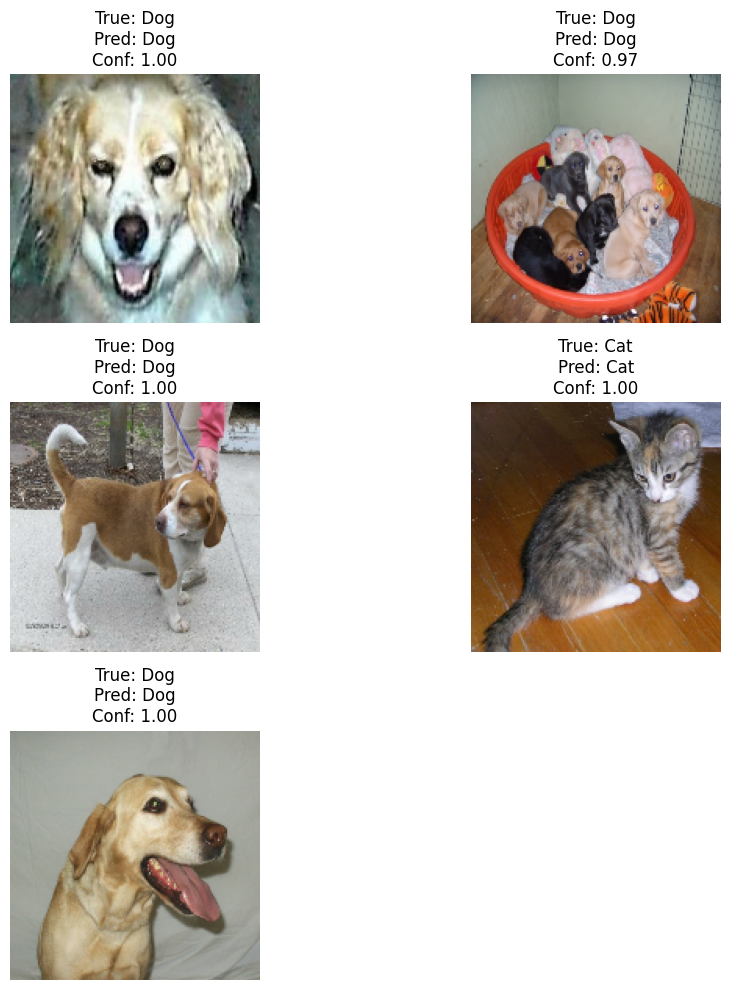

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,10))

for images, labels in validation_dataset.take(1):
    predictions = model.predict(images)

    for i in range(5):
        plt.subplot(3,2,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        pred = predictions[i][0]
        predicted_label = "Dog" if pred > 0.5 else "Cat"
        confidence = pred if pred > 0.5 else 1-pred
        true_label = class_names[int(labels[i])]

        plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}")
        plt.axis("off")

plt.tight_layout()
plt.show()

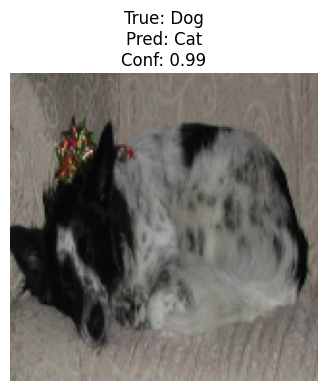

In [25]:
import matplotlib.pyplot as plt
import numpy as np

found = False

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)

    for i in range(len(images)):
        pred = predictions[i][0]
        predicted_label = 1 if pred > 0.5 else 0

        if predicted_label != labels[i].numpy():
            plt.figure(figsize=(4,4))
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[int(labels[i])]
            predicted = class_names[predicted_label]
            confidence = pred if pred > 0.5 else 1-pred

            plt.title(f"True: {true_label}\nPred: {predicted}\nConf: {confidence:.2f}")
            plt.axis("off")
            plt.show()

            found = True
            break

    if found:
        break

if not found:
    print("No misclassified image found in the scanned validation batches.")

Accuracy Results:

The model was trained for 3 epochs using MobileNetV2.

Training Accuracy: 98.2%

Validation Accuracy: 97.9%

Since there is a high validation accuracy it indicates that it was able to classify most images correctly.


Misclassified Eg:-
One image was misclassified by the model.A possible reason for that is that the animal was partially visible , blurred and it is photographed from an unusual angle.


From this I conclude,I have built a cat vs dog image classifier using transfer learning with MobileNetV2.